# Spaceship Titanic

# Introduction

The goal of the Spaceship Titanic project is to predict whether passengers were transported to an alternate dimension during the ship's collision with a spacetime anomaly.
The dataset provides personal records recovered from the ship's damaged computer system, including demographics, cabin information, travel plans, and expenses on luxury amenities.

In this project, we aim to build a baseline model using these features to predict the target variable `Transported`.
The approach includes simple data preprocessing, handling missing values, encoding categorical variables, and training a LightGBM classifier.
This pipeline provides a fast and effective way to generate predictions for the test set and submit them to the competition.

# Requirements

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Data Import

In [2]:
train = pd.read_csv('train.csv')

In [3]:
test = pd.read_csv('test.csv')

In [4]:
sample_sub = pd.read_csv('sample_submission.csv')

In [5]:
sample_sub.head()

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,False
4,0023_01,False


In [6]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


# Exploratory Data Analysis (EDA)

In [7]:
 train.shape

(8693, 14)

In [8]:
test.shape

(4277, 13)

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [10]:
train.columns.tolist()

['PassengerId',
 'HomePlanet',
 'CryoSleep',
 'Cabin',
 'Destination',
 'Age',
 'VIP',
 'RoomService',
 'FoodCourt',
 'ShoppingMall',
 'Spa',
 'VRDeck',
 'Name',
 'Transported']

In [11]:
train.isnull().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


In [12]:
test.isnull().sum()

,0
PassengerId,0
HomePlanet,87
CryoSleep,93
Cabin,100
Destination,92
Age,91
VIP,93
RoomService,82
FoodCourt,106
ShoppingMall,98


In [13]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB


# Data Visualization

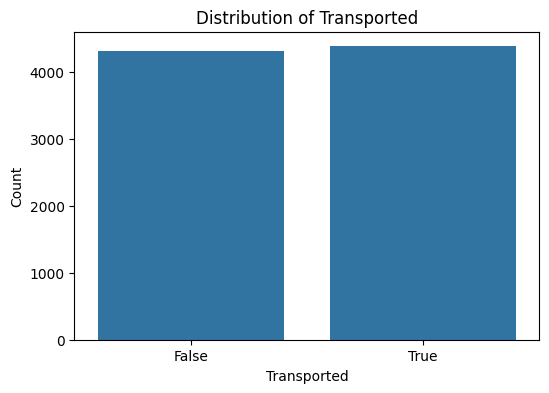

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x=train['Transported'])
plt.title("Distribution of Transported")
plt.xlabel("Transported")
plt.ylabel("Count")
plt.show()

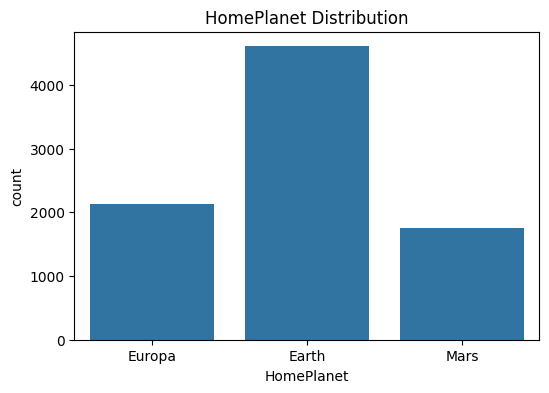

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x=train['HomePlanet'])
plt.title("HomePlanet Distribution")
plt.show()


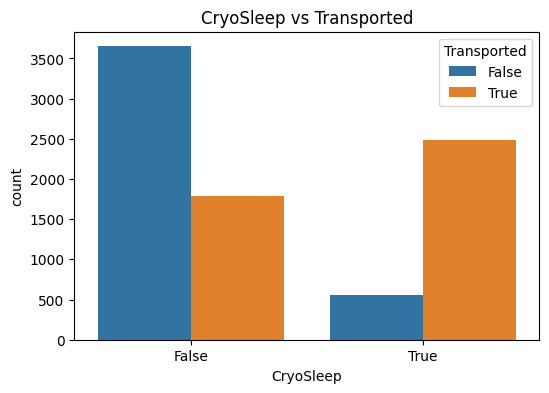

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='CryoSleep', hue='Transported', data=train)
plt.title("CryoSleep vs Transported")
plt.show()

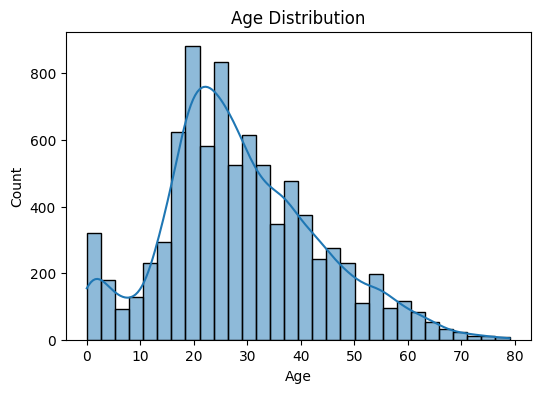

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(train['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# Handle Missing Values

In [18]:
import pandas as pd

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

money_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
cat_cols = ['HomePlanet','CryoSleep','Destination','VIP']

for df in [train, test]:
    df[money_cols] = df[money_cols].fillna(0)
    df['TotalSpend'] = df[money_cols].sum(axis=1)
    df['Age'] = df['Age'].fillna(df['Age'].median())
    for col in cat_cols:
        df[col] = df[col].fillna('Unknown')
    df['CryoSleep'] = df['CryoSleep'].map({'True':True,'False':False,'Unknown':False})
    df['VIP'] = df['VIP'].map({'True':True,'False':False,'Unknown':False})
    df['Deck'] = df['Cabin'].apply(lambda x: str(x).split('/')[0] if pd.notnull(x) else 'Unknown')
    df['CabinNum'] = df['Cabin'].apply(lambda x: str(x).split('/')[1] if pd.notnull(x) else 0).astype(int)
    df['Side'] = df['Cabin'].apply(lambda x: str(x).split('/')[2] if pd.notnull(x) else 'Unknown')

In [19]:
train['CryoSleep'] = train['CryoSleep'].fillna(False)
test['CryoSleep'] = test['CryoSleep'].fillna(False)

train['VIP'] = train['VIP'].fillna(False)
test['VIP'] = test['VIP'].fillna(False)

train['Name'] = train['Name'].fillna('Unknown')
test['Name'] = test['Name'].fillna('Unknown')

train['Cabin'] = train['Cabin'].fillna('Unknown/0/Unknown')
test['Cabin'] = test['Cabin'].fillna('Unknown/0/Unknown')


In [20]:
test.isnull().sum()

,0
PassengerId,0
HomePlanet,0
CryoSleep,0
Cabin,0
Destination,0
Age,0
VIP,0
RoomService,0
FoodCourt,0
ShoppingMall,0


In [21]:
train.isnull().sum()

,0
PassengerId,0
HomePlanet,0
CryoSleep,0
Cabin,0
Destination,0
Age,0
VIP,0
RoomService,0
FoodCourt,0
ShoppingMall,0


#Feature Engineering

In [22]:
# Enforce domain rule: No spending during CryoSleep
for df in [train, test]:
    df.loc[df['CryoSleep'] == True, ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']] = 0

In [23]:
money_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']

for df in [train, test]:
    df['TotalSpend'] = df[money_cols].sum(axis=1)

In [24]:
for df in [train, test]:
    df['HasSpending'] = (df['TotalSpend'] > 0).astype(int)

In [25]:
for df in [train, test]:
    df['LogTotalSpend'] = np.log1p(df['TotalSpend'])

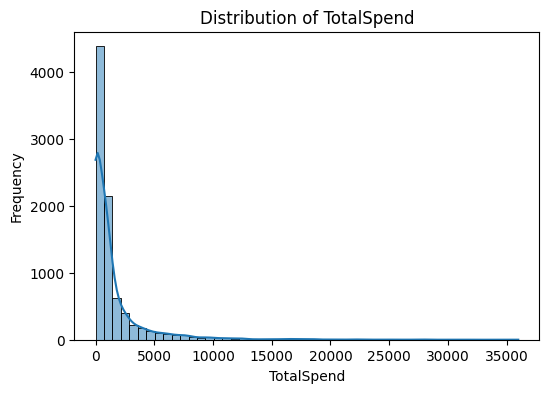

In [26]:
plt.figure(figsize=(6,4))
sns.histplot(train['TotalSpend'], bins=50, kde=True)
plt.title("Distribution of TotalSpend")
plt.xlabel("TotalSpend")
plt.ylabel("Frequency")
plt.show()

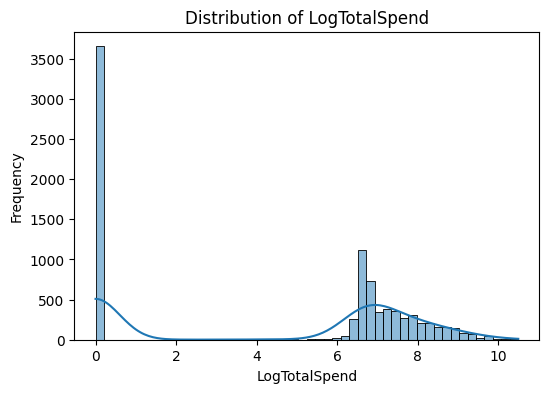

In [27]:
plt.figure(figsize=(6,4))
sns.histplot(train['LogTotalSpend'], bins=50, kde=True)
plt.title("Distribution of LogTotalSpend")
plt.xlabel("LogTotalSpend")
plt.ylabel("Frequency")
plt.show()

# Modeling - Preprocessing & Pipeline Setup

In [28]:
# Features & target
features = ['HomePlanet','CryoSleep','Destination','Age','VIP',
            'TotalSpend','LogTotalSpend','Deck','CabinNum','Side','HasSpending']

X = train[features]
y = train['Transported']

# Categorical & numerical features
categorical_features = ['HomePlanet','Destination','Deck','Side']
numeric_features = ['Age','TotalSpend','LogTotalSpend','CabinNum','CryoSleep','VIP','HasSpending']

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

# Modeling - Model Comparison

In [29]:
"""# Modeling - Model Comparison"""

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_depth=15, min_samples_leaf=2, random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    results[name] = cv_scores.mean()
    print(f"{name} CV Accuracy Mean: {cv_scores.mean():.4f}")

LogisticRegression CV Accuracy Mean: 0.7310
RandomForest CV Accuracy Mean: 0.7390
GradientBoosting CV Accuracy Mean: 0.7199


# Modeling - Best Model Evaluation

Best model: RandomForest with CV Accuracy: 0.7389896445915838
Validation Accuracy: 0.7567567567567568

Classification Report:
               precision    recall  f1-score   support

       False       0.72      0.83      0.77       861
        True       0.80      0.68      0.74       878

    accuracy                           0.76      1739
   macro avg       0.76      0.76      0.76      1739
weighted avg       0.76      0.76      0.76      1739



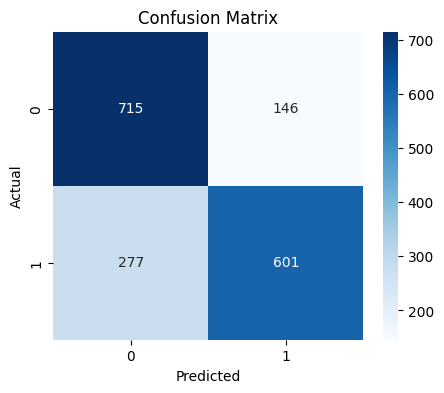

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Select best model
best_model_name = max(results, key=results.get)
print("Best model:", best_model_name, "with CV Accuracy:", results[best_model_name])

best_model = models[best_model_name]

final_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_model)
])

# Train / Validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

final_clf.fit(X_train, y_train)
y_pred = final_clf.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
print("Validation Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_val, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Modeling - Final Training & Submission

In [31]:
# Train on full dataset
final_clf.fit(X, y)

# Predict on test set
test_preds = final_clf.predict(test[features])

# Create submission file
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': test_preds
})
submission.to_csv('submission.csv', index=False)

# Save the model
import joblib
joblib.dump(final_clf, 'spaceship_model.pkl')
print("Final model saved as spaceship_model.pkl")

Final model saved as spaceship_model.pkl


# Conclusion

In this project, I built an end-to-end machine learning pipeline to predict passenger transportation in the Spaceship Titanic dataset. After handling missing values and performing feature engineering (such as enforcing a CryoSleep spending rule and creating features like HasSpending and LogTotalSpend), I compared multiple models using cross-validation. Among Logistic Regression, Random Forest, and Gradient Boosting, Random Forest achieved the best performance with a CV accuracy of around 0.74 and a validation accuracy of about 0.76.

This project focuses on building a clean and reproducible workflow rather than maximizing leaderboard scores. It can be further improved with more advanced feature engineering and hyperparameter tuning.